<a href="https://www.kaggle.com/code/dimassp1/salarypreds-pytorch?scriptVersionId=262800415" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wardabilal/salary-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/salary-prediction-dataset


In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning import LightningModule
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger

from torchmetrics.regression import R2Score, MeanSquaredError, MeanAbsoluteError
from torchmetrics.functional import r2_score, mean_squared_error, mean_absolute_error
!uv pip install pytorch_optimizer
import pytorch_optimizer as optim1
import optuna

pl.seed_everything(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Using Python 3.11.13 environment at: /usr
Resolved 36 packages in 567ms
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
Prepared 1 package in 101ms
Uninstalled 10 packages in 57ms
Installed 11 packages in 21.08s
 - nvidia-cublas-cu12==12.5.3.2
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.5.82
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.5.82
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.5.82
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn

In [3]:
df = pd.read_csv('/kaggle/input/salary-prediction-dataset/Salary_Data.csv')
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [4]:
df.isnull().sum()
df.duplicated().sum()

4912

In [5]:
df.drop_duplicates(inplace=True)
# df.reset_index(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1792 entries, 0 to 6631
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1791 non-null   float64
 1   Gender               1791 non-null   object 
 2   Education Level      1790 non-null   object 
 3   Job Title            1791 non-null   object 
 4   Years of Experience  1790 non-null   float64
 5   Salary               1788 non-null   float64
dtypes: float64(3), object(3)
memory usage: 98.0+ KB


In [6]:
df.dropna(subset=['Salary'], inplace=True)

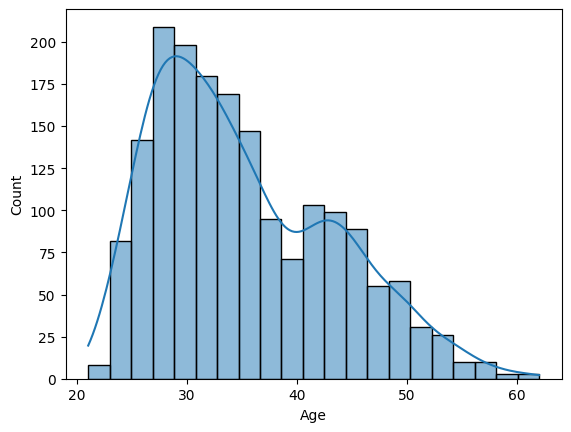

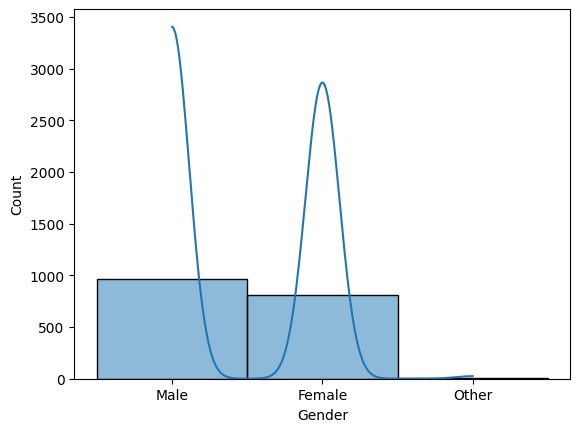

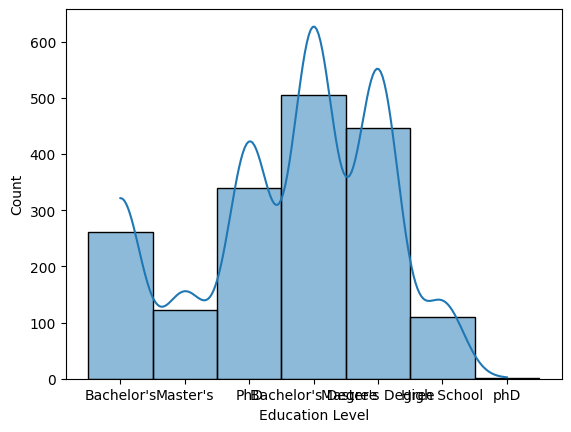

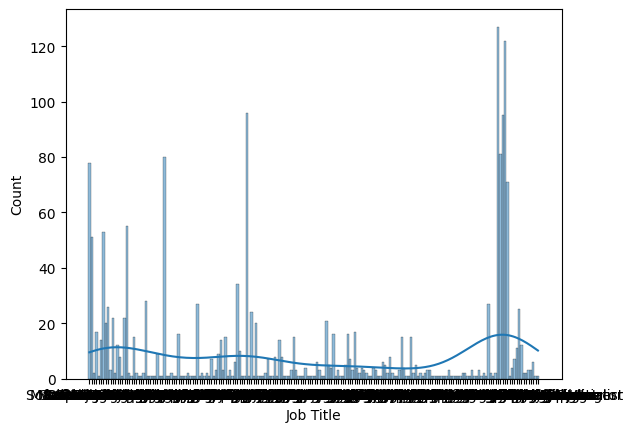

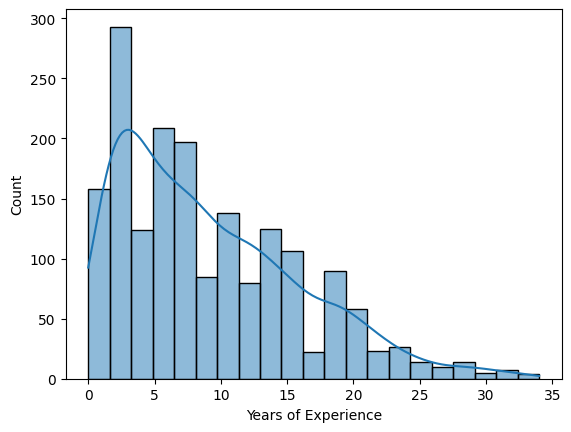

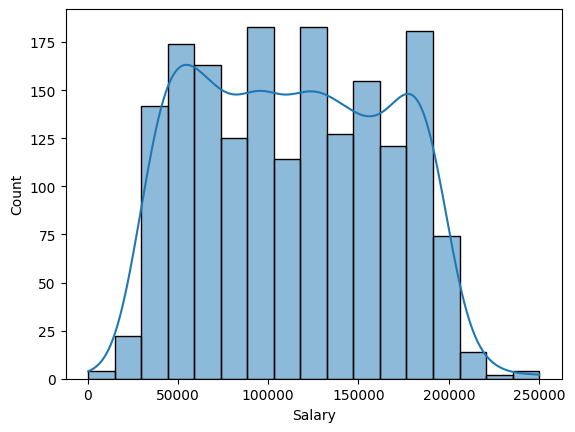

In [7]:
for i in df:
    sns.histplot(df[i], kde=True)
    plt.show()

In [8]:
df['Job Title'].nunique()

192

In [9]:
cat_t = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent'))
])
num_t = Pipeline([
    ('scaler', StandardScaler())
])
cat_c = ColumnTransformer([
    ('col', cat_t, ['Job Title', 'Education Level']),
    ('num', num_t, ['Salary'])
], remainder='passthrough')
df_t = cat_c.fit_transform(df)
df = pd.DataFrame(df_t, index=df.index)
df.rename(
    columns={
        0:'Job Title',
        1: 'Education Level',
        2: 'Salary',
        3: 'Age',
        4: 'Gender',
        5: 'Years of Experience'
    }, inplace=True
)
df['Age'] = df['Age'].astype(float)
df['Years of Experience'] = df['Years of Experience'].astype(float)
df['Salary']= df['Salary'].astype(float)

df

,Job Title,Education Level,Salary,Age,Gender,Years of Experience
0,Software Engineer,Bachelor's,-0.449446,32.0,Male,5.0
1,Data Analyst,Master's,-0.934237,28.0,Female,3.0
2,Senior Manager,PhD,0.714053,45.0,Male,15.0
3,Sales Associate,Bachelor's,-1.031195,36.0,Female,7.0
4,Director,Master's,1.683635,52.0,Male,20.0
...,...,...,...,...,...,...
6623,Digital Marketing Manager,Master's Degree,0.714053,43.0,Female,15.0
6624,Sales Manager,High School,-1.419028,27.0,Male,2.0
6625,Director of Marketing,Bachelor's Degree,-0.643362,33.0,Female,8.0
6628,Sales Director,Bachelor's Degree,-0.449446,37.0,Male,7.0


In [10]:
df['Education Level'] = df['Education Level'].replace({'phD': 'PhD'})

In [11]:
grouped_jobs = {
    'Software Development & Engineering': [
        'Software Engineer',
        'Software Developer',
        'Junior Developer',
        'Software Manager',
        'Web Developer',
        'Senior Software Engineer',
        'Junior Software Developer',
        'Junior Web Developer',
        'Principal Engineer',
        'Senior Software Developer',
        'Junior Web Designer',
        'Junior Software Engineer',
        'Senior Software Architect',
        'Software Engineer Manager',
        'Back end Developer',
        'Full Stack Engineer',
        'Front end Developer',
        'Developer',
        'Front End Developer'
    ],
    'Data Science & Analytics': [
        'Data Analyst',
        'Senior Scientist',
        'Financial Analyst',
        'Business Analyst',
        'Data Scientist',
        'Business Intelligence Analyst',
        'Senior Data Scientist',
        'Research Director',
        'Principal Scientist',
        'Research Scientist',
        'Operations Analyst',
        'Chief Data Officer',
        'Senior Marketing Analyst',
        'Supply Chain Analyst',
        'Senior Business Analyst',
        'Junior Marketing Analyst',
        'Junior Operations Analyst',
        'Junior Data Analyst',
        'Junior Business Analyst',
        'Senior Financial Analyst',
        'Junior Financial Analyst',
        'Senior Operations Analyst',
        'Senior Data Analyst',
        'Junior Data Scientist',
        'Senior Quality Assurance Analyst',
        'Junior Business Operations Analyst',
        'Senior Data Engineer',
        'Director of Data Science'
    ],
    'Management & Directorate': [
        'Senior Manager',
        'Director',
        'Product Manager',
        'Sales Manager',
        'HR Manager',
        'Project Manager',
        'Operations Manager',
        'Marketing Manager',
        'Sales Director',
        'VP of Operations',
        'Software Manager',
        'CEO',
        'Operations Director',
        'Director of Marketing',
        'Customer Service Manager',
        'VP of Finance',
        'Director of Operations',
        'IT Manager',
        'Chief Technology Officer',
        'Senior Project Manager',
        'Supply Chain Manager',
        'Senior Marketing Manager',
        'Public Relations Manager',
        'Product Marketing Manager',
        'Senior HR Manager',
        'Sales Operations Manager',
        'Senior Product Manager',
        'Senior Sales Manager',
        'Director of Sales',
        'Senior Operations Manager',
        'Director of Human Resources',
        'Director of Product Management',
        'Director of Finance',
        'Senior IT Project Manager',
        'Director of Sales and Marketing',
        'Director of Business Development',
        'Senior Marketing Director',
        'Senior Product Development Manager',
        'Junior Operations Manager',
        'Senior Financial Manager',
        'Director of HR',
        'Director of Engineering',
        'Marketing Director',
        'Human Resources Manager'
    ],
    'Sales & Account Management': [
        'Sales Associate',
        'Sales Manager',
        'Sales Director',
        'Sales Executive',
        'Account Manager',
        'Sales Representative',
        'Junior Account Manager',
        'Sales Operations Manager',
        'Junior Sales Representative',
        'Senior Sales Manager',
        'Director of Sales',
        'Senior Sales Representative',
        'Senior Account Manager',
        'Senior Account Executive',
        'Junior Sales Associate'
    ],
    'Marketing & Social Media': [
        'Marketing Analyst',
        'Marketing Coordinator',
        'Marketing Manager',
        'Social Media Specialist',
        'Marketing Specialist',
        'Copywriter',
        'Director of Marketing',
        'Event Coordinator',
        'Social Media Manager',
        'Digital Marketing Manager',
        'Content Marketing Manager',
        'Product Marketing Manager',
        'Senior Marketing Manager',
        'Digital Content Producer',
        'Senior Marketing Analyst',
        'Junior Marketing Analyst',
        'Junior Marketing Manager',
        'Senior Product Marketing Manager',
        'Junior Marketing Specialist',
        'Junior Marketing Coordinator',
        'Senior Marketing Coordinator',
        'Director of Sales and Marketing',
        'Junior Social Media Manager',
        'Senior Marketing Director',
        'Junior Social Media Specialist',
        'Public Relations Manager',
        'Digital Marketing Specialist',
        'Marketing Director',
        'Social M',
        'Social Media Man'
    ],
    'Human Resources (HR)': [
        'HR Manager',
        'Recruiter',
        'HR Generalist',
        'Technical Recruiter',
        'Human Resources Director',
        'Training Specialist',
        'Senior HR Manager',
        'Junior HR Generalist',
        'Senior HR Generalist',
        'Senior Training Specialist',
        'Junior Recruiter',
        'Director of Human Resources',
        'Senior Human Resources Manager',
        'Junior HR Coordinator',
        'Senior Human Resources Coordinator',
        'Senior Human Resources Specialist',
        'Director of Human Capital',
        'Senior HR Specialist',
        'Director of HR',
        'Human Resources Coordinator',
        'Human Resources Manager',
        'Juniour HR Generalist',
        'Juniour HR Coordinator'
    ],
    'IT & Technical Support': [
        'IT Support',
        'Network Engineer',
        'Help Desk Analyst',
        'Technical Support Specialist',
        'IT Support Specialist',
        'Senior IT Support Specialist',
        'Senior IT Project Manager',
        'Senior IT Consultant'
    ],
    'Finance & Accounting': [
        'Financial Analyst',
        'Financial Manager',
        'Accountant',
        'VP of Finance',
        'Junior Accountant',
        'Senior Financial Analyst',
        'Financial Advisor',
        'Senior Accountant',
        'Director of Finance',
        'Junior Financial Analyst',
        'Senior Financial Advisor',
        'Senior Financial Manager',
        'Junior Financial Advisor'
    ],
    'Customer Service & Support': [
        'Customer Service Rep',
        'Customer Success Rep',
        'Customer Service Manager',
        'Customer Success Manager',
        'Customer Service Representative',
        'Junior Customer Support Specialist'
    ],
    'Design & Creative': [
        'Product Designer',
        'UX Designer',
        'Graphic Designer',
        'UX Researcher',
        'Creative Director',
        'Junior Designer',
        'Senior Graphic Designer',
        'Senior Product Designer',
        'Senior UX Designer',
        'Junior UX Designer'
    ],
    'Operations & Supply Chain': [
        'Operations Manager',
        'VP of Operations',
        'Operations Director',
        'Supply Chain Manager',
        'Operations Analyst',
        'Supply Chain Analyst',
        'Junior Operations Analyst',
        'Senior Operations Manager',
        'Senior Operations Analyst',
        'Junior Operations Manager',
        'Senior Operations Coordinator',
        'Junior Operations Coordinator'
    ],
    'Business Development & Strategy': [
        'Business Analyst',
        'Strategy Consultant',
        'Business Development Manager',
        'Senior Consultant',
        'Senior Business Analyst',
        'Junior Business Analyst',
        'Senior Business Development Manager',
        'Director of Business Development',
        'Junior Business Development Associate'
    ],
    'Administrative & General': [
        'Data Entry Clerk',
        'Administrative Assistant',
        'Office Manager',
        'Receptionist',
        'Delivery Driver'
    ],
    'Content & Writing': [
        'Technical Writer',
        'Copywriter',
        'Content Marketing Manager',
        'Digital Content Producer',
        'Junior Copywriter'
    ]
}
job_to_dep = {}
for category, job_list in grouped_jobs.items():
    for job in job_list:
        job_to_dep[job] = category 

In [12]:
df['Job_Category'] = df['Job Title'].map(job_to_dep).copy()
print(df['Job_Category'].nunique())
df['Job_Category'].head(15)

14


0     Software Development & Engineering
1               Data Science & Analytics
2               Management & Directorate
3             Sales & Account Management
4               Management & Directorate
5               Marketing & Social Media
6               Management & Directorate
7             Sales & Account Management
8               Marketing & Social Media
9               Data Science & Analytics
10    Software Development & Engineering
11                  Human Resources (HR)
12                  Finance & Accounting
13              Management & Directorate
14            Customer Service & Support
Name: Job_Category, dtype: object

In [13]:
df.drop(columns='Job Title', inplace=True)

education_level_mapping = {education:i for i, education in enumerate(df['Education Level'].unique())}
df['Education Level'] = df['Education Level'].map(education_level_mapping)
num_education_level = len(education_level_mapping)
embedding_dim_edu = 4

job_cat_map = {cat:i for i, cat in enumerate(df['Job_Category'].unique())}
df['Job_Category'] = df['Job_Category'].map(job_cat_map)
num_job_cat = len(job_cat_map)
embedding_dim_job = 10

gen_cat_map = {cat:i for i, cat in enumerate(df['Gender'].unique())}
df['Gender'] = df['Gender'].map(gen_cat_map)
embedding_dim_gen = 2
num_gen_cat = len(gen_cat_map)
embedding_sizes = [
    (num_education_level, embedding_dim_edu),
    (num_job_cat, embedding_dim_job),
    (num_gen_cat, embedding_dim_gen)

]

In [14]:
X = df.drop(columns=['Salary'], axis=1)
y = df.Salary
index  = df.index
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1341, 5), (447, 5), (1341,), (447,))

In [15]:
X_num_train = X_train.drop(columns=['Education Level', 'Job_Category', 'Gender'], axis=1)
X_num_test = X_test.drop(columns=['Education Level', 'Job_Category', 'Gender'], axis=1)
X_cat_train = X_train[['Education Level', 'Job_Category', 'Gender']]
X_cat_test = X_test[['Education Level', 'Job_Category', 'Gender']]

In [16]:
# X_cat_train['Job_Category'] = X_cat_train['Job_Category'].astype('category').cat.codes
# X_cat_test['Job_Category'] = X_cat_test['Job_Category'].astype('category').cat.codes
# X_cat_train['Education Level'] = X_cat_train[['Education Level', 'Job_Category']].astype('category').cat.codes
# X_cat_test['Education Level'] = X_cat_test['Education Level'].astype('category').cat.codes

In [17]:
cat = X_num_train.select_dtypes(include='object').columns.to_list()
num = X_num_train.select_dtypes(exclude='object').columns.to_list()
num, cat

(['Age', 'Years of Experience'], [])

In [18]:
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('power', PowerTransformer()),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder())
])
pipeline = ColumnTransformer([
    ('num', num_pipe, num),
    ('cat', cat_pipe, cat)
])

X_num_train = pipeline.fit_transform(X_num_train)
X_num_test = pipeline.transform(X_num_test)

In [19]:
def conv_block(in_feature, out_feature, padding=1, stride=1,
             activation="relu", pool =True, maxpool=True, kernel_size=3,
             kernel_size_pool=2, pool_stride=2)-> list[nn.Sequential]:
    layers = [nn.Conv2d(in_feature, out_feature, kernel_size=kernel_size, padding=padding, stride=stride)]
    if activation == "relu":
        layers.append(nn.ReLU())
    elif activation == "leakyrelu":
        layers.append(nn.LeakyReLU())
    elif activation == "sigmoid":
        layers.append(nn.Sigmoid())
    elif activation == "tanh":
        layers.append(nn.Tanh())
    if pool:
        if maxpool:
            layers.append(nn.MaxPool2d(kernel_size=kernel_size_pool, stride=pool_stride))
        else:
            layers.append(nn.AvgPool2d(kernel_size=kernel_size_pool, stride=pool_stride))
    else:
        layers.append(nn.Identity())
    return nn.Sequential(*layers)


def linear_block(in_features, out_features, activation=None, dropout=0.0, batch_norm=None):
    layers = [nn.Linear(in_features, out_features)]
    if batch_norm:
        layers.append(nn.BatchNorm1d(out_features))
    if activation == 'relu':
        layers.append(nn.ReLU())
    elif activation == 'sigmoid':
        layers.append(nn.Sigmoid())
    elif activation == 'tanh':
        layers.append(nn.Tanh())
    elif activation == 'leakyrelu':
        layers.append(nn.LeakyReLU())
    elif activation == 'mish': layers.append(nn.Mish())
    elif activation == 'softmax':
        layers.append(nn.Softmax(dim=1))
    elif activation == 'elu':
        layers.append(nn.ELU())
    elif activation == 'selu':
        layers.append(nn.SELU())
    elif activation == 'lsoftmax':
        layers.append(nn.LogSoftmax(dim=1))
    if dropout > 0.0:
        layers.append(nn.Dropout(dropout))
    return nn.Sequential(*layers)

In [20]:
from typing import Any


class EmbbedDataset(Dataset):
    def __init__(self, X_cat, X_num, y) -> None:
        super().__init__()
        self.categorical = torch.tensor(X_cat, dtype=torch.long)
        self.numeric = torch.tensor(X_num, dtype=torch.float32)
        self.labels = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.categorical[idx], self.numeric[idx], self.labels[idx]
    
class ANN(LightningModule):
    def __init__(self, embedding_sizes, num_numerical) -> None:
        super().__init__()
        self.embedding = nn.ModuleList([nn.Embedding(vocab_size, dim) for vocab_size, dim in embedding_sizes])
        num_embedding_dim = sum(dim for _, dim in embedding_sizes)
        self.fc = nn.Sequential(
            linear_block(num_embedding_dim+ num_numerical, 64, activation='mish', batch_norm=True),
            linear_block(64, 32, activation='mish', batch_norm=True),
            linear_block(32, 8, activation='mish', batch_norm=True),
            linear_block(8, 1, activation=None, batch_norm=None)
        )
    def forward(self, X_cat, X_num):
        embedd_feature = [emb(X_cat[:, i]) for i, emb in enumerate(self.embedding)]
        total_embedd = torch.cat(embedd_feature, dim=1)
        combine_feature = torch.cat([total_embedd, X_num], dim=1)
        return self.fc(combine_feature)
    
class PL(LightningModule):
    def __init__(self, model, learning_rate) -> None:
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate
        self.criterion = nn.HuberLoss()
        self.r2 = R2Score()
    
    def forward(self, X_cat, X_num) -> Any:
        return self.model(X_cat, X_num)

    def training_step(self, batch, batch_idx):
        X_cat, X_num, labels = batch
        labels = labels.unsqueeze(1)
        outputs = self(X_cat, X_num)
        loss = self.criterion(outputs, labels)
        r2 = self.r2(outputs, labels)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        self.log('train_r2', r2, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        X_cat, X_num, labels = batch
        labels = labels.unsqueeze(1)
        outputs = self(X_cat, X_num)
        loss = self.criterion(outputs, labels)
        r2 = self.r2(outputs, labels)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True, logger=True)
        self.log('val_r2', r2, on_epoch=True, prog_bar=True, logger=True)

    def test_step(self, batch, batch_idx):
        X_cat, X_num, labels = batch
        labels = labels.unsqueeze(1)
        outputs = self(X_cat, X_num)
        loss = self.criterion(outputs, labels)
        r2 = self.r2(outputs, labels)
        self.log('test_loss', loss, on_epoch=True, prog_bar=True, logger=True)
        self.log('test_r2', r2, on_epoch=True, prog_bar=True, logger=True)

    def backward(self, loss, *args, **kwargs):
        loss.backward(create_graph=True)

    def configure_optimizers(self):
        optimizer = optim1.AdamWSN(self.parameters(), lr=self.learning_rate)
        return optimizer

    def predict_step(self, batch, batch_idx, dataloader_idx=None):
        X_cat, X_num, _ = batch
        return self(X_cat, X_num)

In [21]:
if torch.cuda.is_available():
    accelerator_type = 'gpu'
    devices_to_use = 1
else:
    accelerator_type = 'cpu'
    devices_to_use = 'auto'

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath='checkpoints/',
    filename='Salary-{epoch:02d}-{val_loss:.2f}',
    save_top_k=1,
    mode='min'
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min',
)
lr_monitor_callback = LearningRateMonitor(logging_interval='epoch')

trainer1 = pl.Trainer(
    max_epochs=300,
    callbacks=[checkpoint_callback, early_stopping, lr_monitor_callback],
    logger=TensorBoardLogger("tb_logs", name="simple_model_experiment"),
    accelerator=accelerator_type,
    devices=devices_to_use,
    log_every_n_steps=10,
    deterministic=True,
    gradient_clip_val=1.0,
    enable_progress_bar=False
)

In [22]:
bs = 256
trainset = EmbbedDataset(X_cat_train.values, X_num_train, y_train.values)
trainloader = DataLoader(trainset, batch_size=bs, shuffle=True)

testset = EmbbedDataset(X_cat_test.values, X_num_test, y_test.values)
testloader = DataLoader(testset, batch_size=bs, shuffle=False)

In [23]:
feature, feature1, target = next(iter(testloader))
feature.shape, feature1.shape, target.shape

(torch.Size([256, 3]), torch.Size([256, 2]), torch.Size([256]))

In [24]:
model = PL(ANN(embedding_sizes, feature1.shape[1]), learning_rate=1e-3)

In [25]:
trainer1.fit(model, trainloader, testloader)

2025-09-19 13:12:30.119242: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758287550.450855      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758287550.541694      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [26]:
trainer1.validate(model, testloader, ckpt_path='best')

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │    0.04519905894994736    │
│          val_r2           │    0.9106497764587402     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.04519905894994736, 'val_r2': 0.9106497764587402}]